In [9]:
from noise_testing import TvbModel
from datetime import datetime
import numpy as np
import scipy
from scipy.stats import gaussian_kde

In [10]:
def run_seeded_tvb(init_seed, sample_size):
    res = []
    for i in range(init_seed, init_seed + sample_size):
        m = TvbModel(noise_seed=i)
        res.append(m.run()[0][1][:, :, :, 0][0][0][0])
    return np.r_[res]


In [11]:
begin = datetime.now()
print(begin)
sample_size = 300
data = run_seeded_tvb(0, sample_size)
data2 = run_seeded_tvb(sample_size, sample_size)
print(scipy.stats.ks_2samp(data, data2))
print(datetime.now() - begin)

2025-10-06 17:17:46.322920
KstestResult(statistic=0.07666666666666666, pvalue=0.34165950354815394, statistic_location=0.9792762386506525, statistic_sign=1)
0:00:03.963263


In [12]:
from matplotlib import pyplot as plt

def show_plot(data_from_whatever):
    kde = gaussian_kde(data_from_whatever)
    x = np.linspace(data_from_whatever.min(), data_from_whatever.max(), 200)
    plt.plot(x, kde(x), label="KDE Estimate")
    plt.hist(data_from_whatever, bins=50, density=True, alpha=0.5)
    plt.legend()
    plt.title("Exponential Distribution (KDE vs Histogram)")
    plt.show()



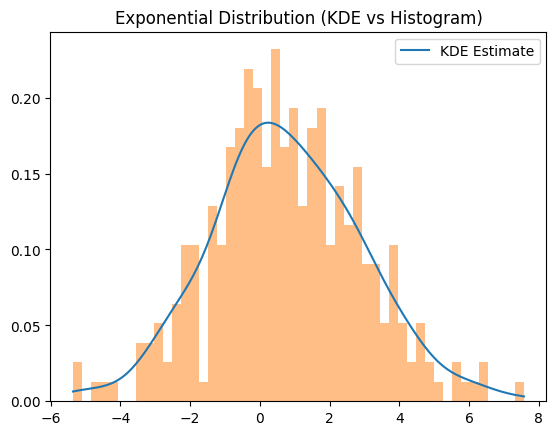

In [13]:
show_plot(data)

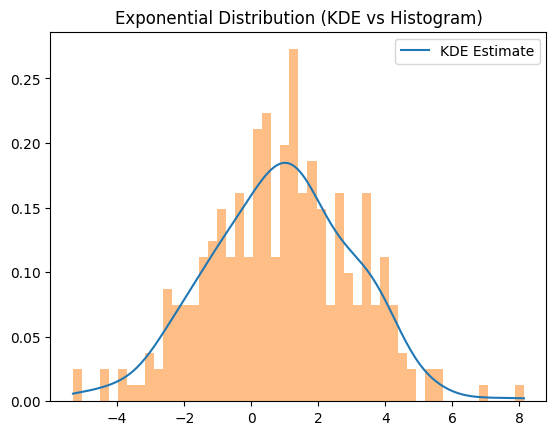

In [ ]:
show_plot(data2)

In [69]:
rng = np.random.default_rng()

sample_size = 10000000

print(scipy.stats.ks_2samp(rng.normal(loc=0, scale=1, size=sample_size), rng.normal(loc=0, scale=1, size=sample_size)))
# print(datetime.now() - begin)

KstestResult(statistic=0.00036089999999999733, pvalue=0.5326811368389051, statistic_location=-0.648743796789469, statistic_sign=-1)
